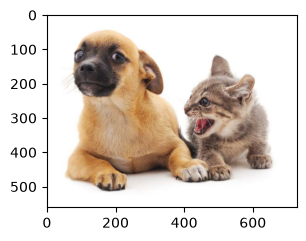

In [1]:
import torch
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (3.5, 2.5)

img = plt.imread('catdog.jpg')
plt.imshow(img)
plt.show()

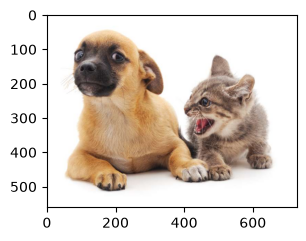

In [2]:
import cv2

plt.rcParams['figure.figsize'] = (3.5, 2.5)

img_bgr = cv2.imread('catdog.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

边界框的两种表达方式：
- 左上角 + 右下角的坐标
- 中心坐标 + 框的长、宽

In [8]:
from matplotlib.patches import Rectangle

def box_corner_to_center(boxes):
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2   # 中心x
    cy = (y1 + y2) / 2   # 中心y
    w = x2 - x1          # 宽度
    h = y2 - y1          # 高度
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes

def box_center_to_corner(boxes):
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

def bbox_to_rect(bbox, color, linewidth=1.5):
    # (左上x,左上y,右下x,右下y) → matplotlib矩形参数：起点(x,y),宽,高
    return Rectangle(
        xy=(bbox[0], bbox[1]), 
        width=bbox[2]-bbox[0], 
        height=bbox[3]-bbox[1],
        fill=False, edgecolor=color, linewidth=linewidth
    )

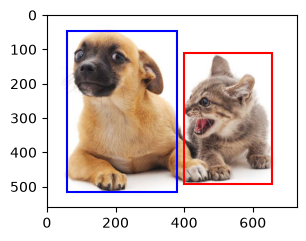

In [9]:
dog_bbox = [60.0, 45.0, 378.0, 516.0]
cat_bbox = [400.0, 112.0, 655.0, 493.0]
boxes = torch.tensor([dog_bbox, cat_bbox])

plt.rcParams['figure.figsize'] = (3.5, 2.5)
img = plt.imread('catdog.jpg')
fig, ax = plt.subplots()
ax.imshow(img)

# 添加边框
ax.add_patch(bbox_to_rect(dog_bbox, 'blue'))
ax.add_patch(bbox_to_rect(cat_bbox, 'red'))
plt.show()

In [ ]:
def multibox_prior_full(data, sizes, ratios):
    """
    每个像素生成 sizes × ratios 全部组合锚框
    data: Tensor(N,C,H,W)
    sizes: list 缩放比
    ratios: list 宽高比
    return: (1, H*W*K, 4)    [x1,y1,x2,y2] 归一化坐标 [0,1]
    """

    in_height, in_width = data.shape[-2:]
    device = data.device
    num_sizes = len(sizes)
    num_ratios = len(ratios)
    boxes_per_pixel = num_sizes * num_ratios   # 核心改动：全排列总数

    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)

    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height
    steps_w = 1.0 / in_width 

    # 生成所有像素中心点
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # ========== 生成全部 s × r 组合 ==========
    # 广播构造全部配对
    s_grid, r_grid = torch.meshgrid(size_tensor, ratio_tensor, indexing="ij")
    s_flat = s_grid.reshape(-1)
    r_flat = r_grid.reshape(-1)

    w = s_flat * torch.sqrt(r_flat)
    h = s_flat / torch.sqrt(r_flat)

    # 构造偏移 [-w/2, -h/2, w/2, h/2]
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(in_height * in_width, 1) / 2

    # 中心点扩展：每个中心点重复 boxes_per_pixel 次
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1)
    out_grid = out_grid.repeat_interleave(boxes_per_pixel, dim=0)

    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)


def show_bboxes(axes, bboxes, labels=None, colors=None):
    """显示所有边界框"""
    
    def _make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = _make_list(labels)
    colors = _make_list(colors, ['b', 'g', 'r', 'm', 'c'])

    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)

        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w'
            axes.text(
                bbox[0], bbox[1], labels[i],
                color=text_color,
                 va='top',
                bbox=dict(facecolor=color, alpha=0.6)
            )

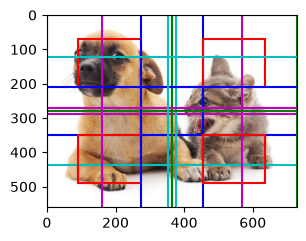

In [15]:
if __name__ == "__main__":
    
    img = plt.imread("catdog.jpg")
    h, w = img.shape[:2]

    X = torch.rand(1, 3, 2, 2)
    sizes = [0.75, 0.5, 0.25]
    ratios = [1, 2, 0.5]

    anchors = multibox_prior(X, sizes, ratios)
    boxes = anchors.squeeze(0)

    boxes[:, [0, 2]] *= w
    boxes[:, [1, 3]] *= h

    label_list = []
    for s in sizes:
        for r in ratios:
            label_list.append(f"s={s}, r={r}")

    fig, ax = plt.subplots()
    ax.imshow(img)
    show_bboxes(ax, boxes)
    plt.show()

In [ ]:
def display_anchors(fmap_w, fmap_h, s, img):
    """
    可视化锚框分布
    fmap_w, fmap_h：模拟特征图的宽、高
    s：锚框基础缩放尺度
    """

    h, w = img.shape[:2]
    # 模拟特征张量
    fmap = torch.zeros((1, 10, fmap_h, fmap_w))
    # 生成锚框
    anchors = multibox_prior_full(fmap, sizes=s, ratios=[1, 2, 0.5])
    # 归一化坐标 -> 原图像素坐标
    bbox_scale = torch.tensor([w, h, w, h])
    anchors_pixel = anchors[0] * bbox_scale

    fig, ax = plt.subplots(figsize=(8,6))
    ax.imshow(img)
    show_bboxes(ax, anchors_pixel)
    plt.show()
    return anchors_pixel

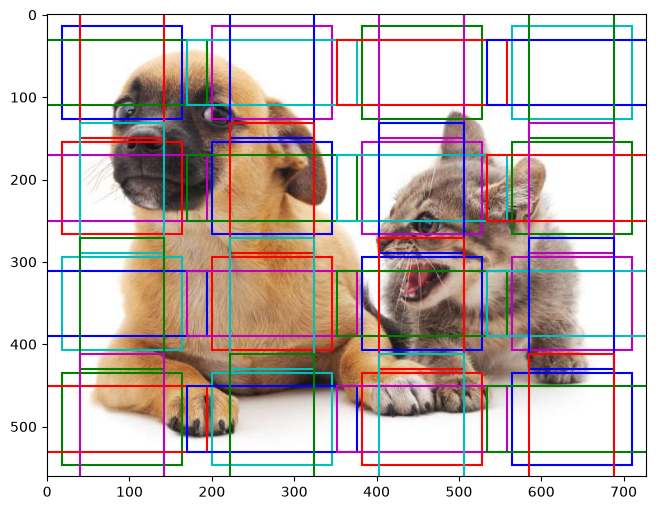

In [20]:
anchors_pixel = display_anchors(fmap_w=4, fmap_h=4, s=[0.2], img=img)